# EDA for the Datasets

## data inspection

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
## explore the dataset
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
df.head()
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

## Data prepration

### I have noticed that Merchant name is begin by M and Customer name is beign by C

In [24]:
# let's add new column that tell about the origins and destination type
df['OrigType'] = df['nameOrig'].str[0]
df['DestType'] = df['nameDest'].str[0]

### let's cancle the ids column of the Orig and Dest (they didn't make any sense)

In [25]:
column_to_drop = ['nameOrig', 'nameDest']
df = df.drop(columns=column_to_drop)

## Data visilsation

### univariate visilisation

#### the type column visilisation

C:\Users\DCS\AppData\Local\Temp\ipykernel_19640\3671843343.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


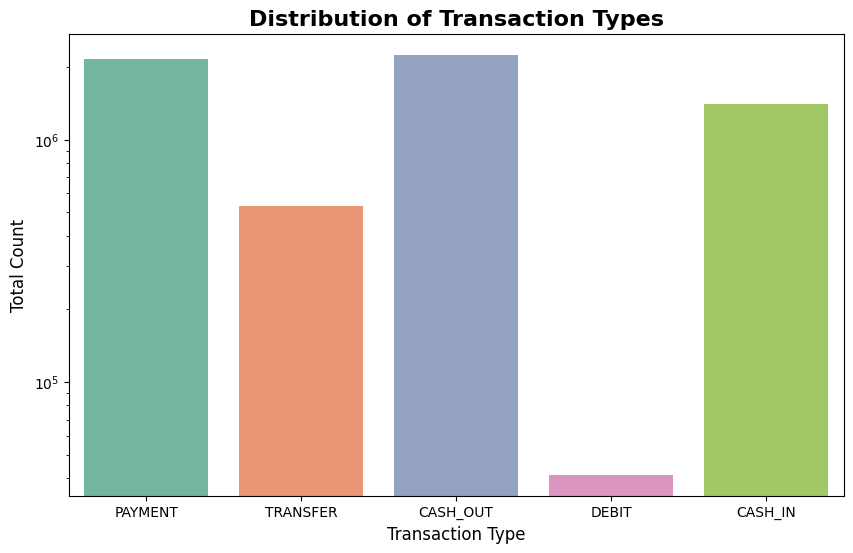

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(x='type', data=df, palette='Set2')

plt.title('Distribution of Transaction Types', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

#### the amount column outliers visilisation

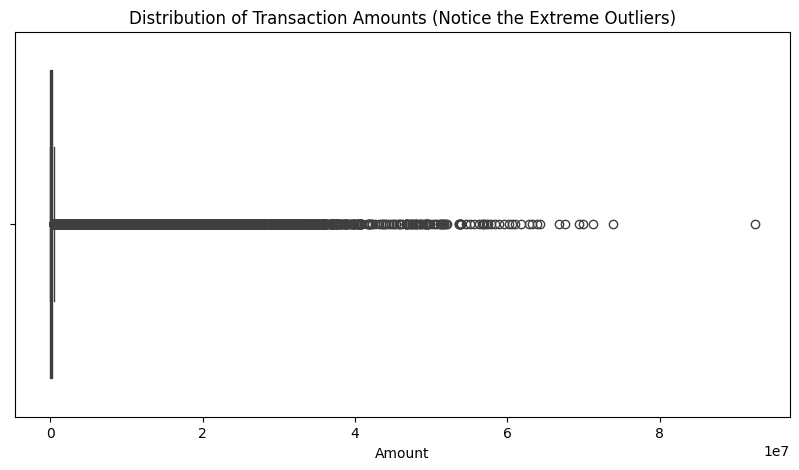

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['amount'])
plt.title('Distribution of Transaction Amounts (Notice the Extreme Outliers)')
plt.xlabel('Amount')
plt.show()

#### the OrigType, DestType column visilisation

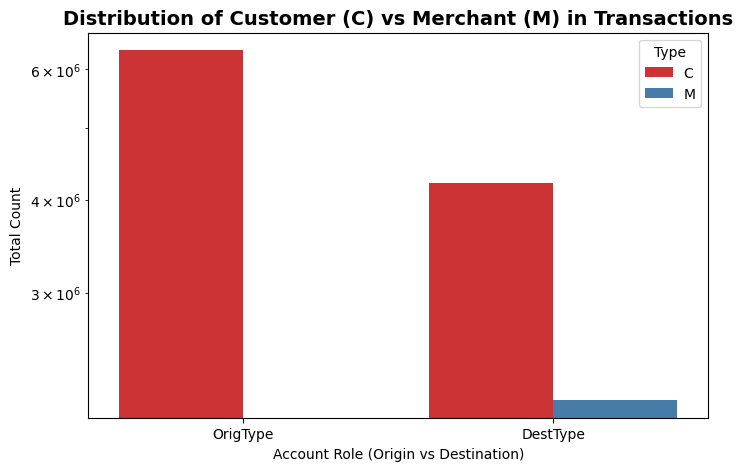

In [ ]:
types_df = df[['OrigType', 'DestType']].melt(var_name='Role', value_name='Type')
plt.figure(figsize=(8, 5))
sns.countplot(x='Role', hue='Type', data=types_df, palette='Set1')
plt.title('Distribution of Customer (C) vs Merchant (M) in Transactions', fontsize=14, fontweight='bold')
plt.ylabel('Total Count')
plt.xlabel('Account Role (Origin vs Destination)')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

#### the oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest column visilisation

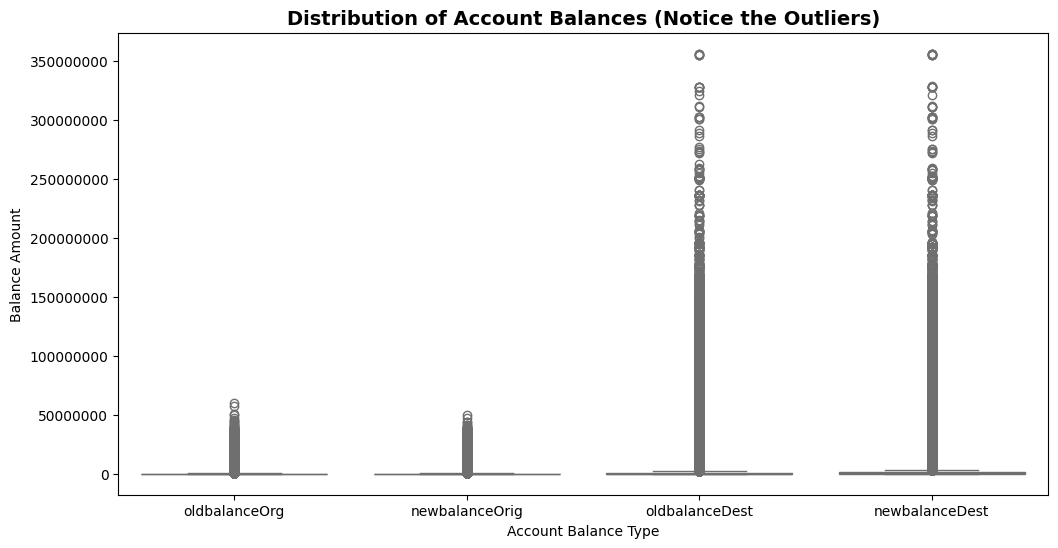

In [30]:
plt.figure(figsize=(12, 6))

balances = df[['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']]
sns.boxplot(data=balances, palette='pastel')
plt.title('Distribution of Account Balances (Notice the Outliers)', fontsize=14, fontweight='bold')
plt.ylabel('Balance Amount')
plt.xlabel('Account Balance Type')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

#### isFraud column visilasation

C:\Users\DCS\AppData\Local\Temp\ipykernel_19640\2695608369.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='isFraud', palette='Set2')


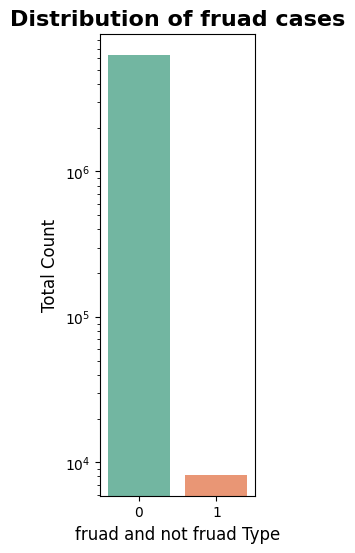

In [ ]:
plt.figure(figsize=(2, 6))

sns.countplot(data=df, x='isFraud', palette='Set2')
plt.title('Distribution of fruad cases', fontsize=16, fontweight='bold')
plt.xlabel('fruad and not fruad Type', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.yscale('log')
plt.show()